In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
# choose window 
from tkinter import Tk
from tkinter.filedialog import askopenfilename
print("libraries has loaded")

libraries has loaded


## Import Dataset Throw Selection Window 

In [2]:
Tk().withdraw()  # يخفي النافذة الرئيسية

file_path = askopenfilename()

## Load_Dataset Function

In [3]:

def load_dataset(path:str)->pd.DataFrame:
    try:
        if path.split('.')[1] == 'xlsx' : 
            df = pd.read_excel(path)
            print(f'''
                Excel File has loaded successfully ✅
                Columns : {df.shape[1]}
                Rows : {df.shape[0]}
                ''')
        elif path.split('.')[1] == 'csv':
            try:
                df = pd.read_csv(path,encoding='utf-8')
            except UnicodeDecodeError:
                print('UTF-8 format doesn\'t working - trying latin1 💥')
                try:
                    df = pd.read_csv(path,encoding='latin1')
                except UnicodeDecodeError:
                    print('latin1 format doesn\'t working')
            print(f'''
                Data has loaded successfully ✅
                Columns : {df.shape[1]}
                Rows : {df.shape[0]}
                ''')
        else:
            print('This file is not CSV or Excel file 😮')
        return df 
    except FileNotFoundError:
        print('Please select an existed file')
    except Exception as e : 
        print(f"ُError occurred {e}")

In [4]:
df = load_dataset(file_path)


                Data has loaded successfully ✅
                Columns : 11
                Rows : 20575
                


## Not Reusable Steps 

#### Handling Data Types

In [5]:
df['Quantity'] = df['Quantity'].astype('Int64')

In [6]:
df.dtypes

Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity              Int64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied       bool
dtype: object

## EDA 

In [7]:
df.head(20)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_8529373,CUST_24,Butchers,Item_24_BUT,39.5,6,237.0,Credit Card,In-store,2022-01-01,True
1,TXN_7949162,CUST_11,Furniture,Item_6_FUR,12.5,4,50.0,Credit Card,In-store,2022-01-01,True
2,TXN_2751393,CUST_16,Food,Item_18_FOOD,30.5,10,305.0,Digital Wallet,In-store,2022-01-01,True
3,TXN_9364474,CUST_19,Food,Item_22_FOOD,36.5,3,109.5,Cash,In-store,2022-01-01,False
4,TXN_3113686,CUST_06,Electric household essentials,Item_21_EHE,35.0,10,350.0,Cash,Online,2022-01-01,True
5,TXN_1519499,CUST_15,Computers and electric accessories,Item_6_CEA,12.5,6,75.0,Credit Card,Online,2022-01-01,True
6,TXN_6329331,CUST_24,Beverages,Item_8_BEV,15.5,5,77.5,Credit Card,Online,2022-01-01,True
7,TXN_6950467,CUST_01,Computers and electric accessories,Item_6_CEA,12.5,6,75.0,Digital Wallet,In-store,2022-01-01,True
8,TXN_2070726,CUST_22,Milk Products,Item_6_MILK,12.5,5,62.5,Digital Wallet,In-store,2022-01-01,False
9,TXN_2489260,CUST_17,Butchers,Item_20_BUT,33.5,7,234.5,Digital Wallet,In-store,2022-01-01,True


#### Data Info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20575 entries, 0 to 20574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    20575 non-null  str    
 1   Customer ID       20575 non-null  str    
 2   Category          20575 non-null  str    
 3   Item              20575 non-null  str    
 4   Price Per Unit    20575 non-null  float64
 5   Quantity          20575 non-null  Int64  
 6   Total Spent       20575 non-null  float64
 7   Payment Method    20575 non-null  str    
 8   Location          20575 non-null  str    
 9   Transaction Date  20575 non-null  str    
 10  Discount Applied  20575 non-null  bool   
dtypes: Int64(1), bool(1), float64(2), str(7)
memory usage: 1.6 MB


#### Data Description 

In [9]:
# Numeric 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price Per Unit,20575.0,23.354241,10.714447,5.0,14.0,23.0,32.0,41.0
Quantity,20575.0,5.559757,2.786079,1.0,3.0,6.0,8.0,10.0
Total Spent,20575.0,130.261725,93.617921,5.0,52.0,109.5,192.0,410.0


In [10]:
# For Categorical data
df.describe(include='object').T
#top : هو القيمة الاكتر تكراراً 
#freq : هو عدد مرات تكرار القيمة دي

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_12232\2194051700.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Transaction ID,20575,20575,TXN_8529373,1
Customer ID,20575,100,CUST_13,668
Category,20575,8,Milk Products,2618
Item,20575,200,Item_2_BEV,230
Payment Method,20575,3,Cash,7028
Location,20575,2,Online,10391
Transaction Date,20575,1716,2022-05-30,26


### Missing Values 

In [11]:
Missing_summery = pd.DataFrame({
    'Missing Values' : df.isnull().sum(),
    'Missing Percentage %': df.isnull().mean()*100
})
Missing_summery[Missing_summery['Missing Percentage %'] > 0].sort_values("Missing Values",ascending=False)

,Missing Values,Missing Percentage %


# Functions 

## Removing Duplicates Function 

In [12]:
def Remove_Duplicates(data:pd.DataFrame)->pd.DataFrame:
    try:
        before = len(data)
        cleaned = data.drop_duplicates()
        after = len(cleaned)
        print(f'Number Of Duplicates Rows : {before-after} 😮')
        return cleaned
    except Exception as e :
        print(f'Error In Remove_Duplicated Function 💥 : {e}')
        return data 

In [13]:
df = Remove_Duplicates(df)

Number Of Duplicates Rows : 0 😮


## Fill With What Function

In [14]:
def Fill_With_What(Col: str, Data: pd.DataFrame):
    series = Data[Col].dropna()
    skewness = series.skew()

    # Skewed distribution
    if abs(skewness) > 0.5:
        return "median"

    # Outlier check
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    if len(outliers) > 0:
        return "median"

    return "mean"

## Handling Missing Values Function (handle numeric - objects - datetime)

In [15]:
# 👉 This function will exclude Special Columns 👈
def Handling_Missing_Values(dataset:pd.DataFrame , SpecialColumns=[])->pd.DataFrame:
    # Categorical data first
    try:
        data = dataset.copy()
        data = data.dropna(how='all') # All Columns Are Null 
        data = data.replace({
            'N/a':np.nan,
            '': np.nan
        })

        numeric_columns = data.select_dtypes(include=np.number).columns
        categorical_columns = data.select_dtypes(include=['object']).columns
        date_columns = data.select_dtypes(include='datetime')
        # Categorical Data
        for col in categorical_columns:
            if data[col].isnull().sum() > 0 and col not in SpecialColumns:
                Value = data[col].mode()[0]
                print(f'{col} has : {data[col].isnull().sum()} Missing ⚠️ it will filled by Mode : {Value}')
                data[col] = data[col].fillna(Value)
        # Numeric Data
        for col in numeric_columns:
            Numericfill = Fill_With_What(col,data) # Will Return Mean or Median Depend on Skewness
            if data[col].isnull().sum() > 0 and col not in SpecialColumns:
                # To specify column data type 
                #dtype = str(data[col].dtype).lower()
                Value = round(data[col].median(),2) if Numericfill.lower() == 'median' else  data[col].mean()
                print(f'{col} has : {data[col].isnull().sum()} Missing ⚠️ it will filled by median : {Value}')
                data[col] = data[col].fillna(Value)
        # Date Data
        for col in date_columns: 
            if data[col].isnull().sum() > 0 and col not in SpecialColumns:
                date_one_day_before = data[col] - pd.DateOffset(days=1) # Date Column - one day for (For Backward fill)
                date_one_day_after = data[col] + pd.DateOffset(days=1) # Date Column + one day (For Forward fill)

                data[col] = data[col].fillna( 
                    date_one_day_before.bfill() # هيملي من الي بعده 
                )

                data[col] = data[col].fillna(  # هيملي من الي قبله 
                    date_one_day_after.ffill()
                )
                
        print('Data Filled Successfully ✅')
        return data
    except Exception as e :
        print(f'Error In Handling_Missing_Values Function 💥 {e}')
            

In [16]:
Flag = True 
SpecialList = ['Price Per Unit','Quantity','Item','Total Spent']
while Flag:
    item = input("please input the special columns \n To terminate Type Stop")
    if item.lower() == 'stop':
        Flag = False
        break
    SpecialList.append(item)
    
df = Handling_Missing_Values(df,SpecialList)

Data Filled Successfully ✅


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_12232\2121833005.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=['object']).columns


## Cleaning_Unwanted_Spaces

def Clean_Unwanted_Spaces(data : pd.DataFrame)->pd.DataFrame:
    try : 
        Categorical_Column = data.select_dtypes(include=['object','string'])
        for col in Categorical_Column: 
            data[col] = data[col].str.strip()
        return data
    except Exception as e : 
        print(f"Error occured in Clean_Unwanted_Spaces Function {e}")
        
df = Clean_Unwanted_Spaces(df)

# Special Columns Handling

## 1- Date Column

In [17]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'],errors='coerce')
df[df['Transaction Date'] > pd.to_datetime('2026-8-15')]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
20119,TXN_10006357,CUST_097,Milk Products,Item_7_MILK,14.0,1,14.0,Credit Card,Online,2026-08-16,True
20120,TXN_10006686,CUST_028,Butchers,Item_15_BUT,26.0,2,52.0,Cash,In-store,2026-08-16,False
20121,TXN_10006506,CUST_079,Milk Products,Item_8_MILK,15.5,3,46.5,Credit Card,In-store,2026-08-16,False
20122,TXN_10007761,CUST_100,Milk Products,Item_13_MILK,23.0,2,46.0,Digital Wallet,In-store,2026-08-16,False
20123,TXN_10003300,CUST_054,Patisserie,Item_13_PAT,23.0,5,115.0,Credit Card,Online,2026-08-16,True
...,...,...,...,...,...,...,...,...,...,...,...
20570,TXN_10004889,CUST_049,Furniture,Item_1_FUR,5.0,5,25.0,Credit Card,Online,2026-09-12,True
20571,TXN_10007491,CUST_08,Food,Item_12_FOOD,21.5,9,193.5,Credit Card,In-store,2026-09-12,True
20572,TXN_10003874,CUST_055,Furniture,Item_5_FUR,11.0,5,55.0,Digital Wallet,Online,2026-09-12,False
20573,TXN_10006594,CUST_18,Food,Item_17_FOOD,29.0,7,203.0,Digital Wallet,In-store,2026-09-12,True


## 2- Quantity Column

In [18]:
Quantity_In_Item = df.groupby('Category')['Quantity'].median()
# Map : بتطابق الكاتيجوري الي في الداتا فريم مع ال index of series 
df['Quantity'] = df['Quantity'].fillna(df['Category'].map(Quantity_In_Item))

Quantity_In_Item

Category
Beverages                             6.0
Butchers                              5.0
Computers and electric accessories    6.0
Electric household essentials         6.0
Food                                  6.0
Furniture                             6.0
Milk Products                         6.0
Patisserie                            6.0
Name: Quantity, dtype: Float64

## 3- Fill Unit Price With (Price Per Unit/Total spent)

In [19]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] * df['Quantity'])

## 4- Item Column

### 1- Try to fill item name using its price in the same category 


In [20]:
#اتأكد من هل فيه منتجات عندها سعر و معندهاش اسم

len(df[(df['Item'].isnull()) & (df['Price Per Unit'].notnull())])

0

In [21]:
# Q1 هل سعر المنتج يقدر يميز كل منتج داخل كل كاتيجوري 
# هل فيه اكتر من منتج في نفس الكاتيجوري ليه نفس السعر ❎

Cat_Price_Group = df.groupby(['Category','Price Per Unit']).agg(
    IsPriceUnique = ('Item','nunique'), # number of unique items in each group 
    name = ('Item','max')
).reset_index()
Cat_Price_Group
# so the Price Can uniquely identify each item 

,Category,Price Per Unit,IsPriceUnique,name
0,Beverages,5.0,1,Item_1_BEV
1,Beverages,6.5,1,Item_2_BEV
2,Beverages,8.0,1,Item_3_BEV
3,Beverages,9.5,1,Item_4_BEV
4,Beverages,11.0,1,Item_5_BEV
...,...,...,...,...
195,Patisserie,35.0,1,Item_21_PAT
196,Patisserie,36.5,1,Item_22_PAT
197,Patisserie,38.0,1,Item_23_PAT
198,Patisserie,39.5,1,Item_24_PAT


In [22]:
# Filling Item depending on (Category , price per unit)

item_mapping = ( #(Category , Price Per Unit,Item)
    df.dropna(subset=['Item'])
      .drop_duplicates(['Category', 'Price Per Unit'])
      .set_index(['Category', 'Price Per Unit'])['Item']
)
mapped_items = pd.Series(
    df.set_index(['Category', 'Price Per Unit']).index.map(item_mapping),
    index=df.index
)
df['Item'] = df['Item'].fillna(
    mapped_items
)

In [23]:
Missing_summery = pd.DataFrame({
    'Missing Values' : df.isnull().sum(),
    'Missing Percentage %': df.isnull().mean()*100
})
Missing_summery[Missing_summery['Missing Percentage %'] > 0].sort_values("Missing Values",ascending=False)

,Missing Values,Missing Percentage %


# Working on Outliers 

In [24]:
# This function need series , will return if there are any outliers or not (IQR Approach)

def OutlierCheck(Col:pd.Series): 
    # apply inter quartile range method
    Q1 = Col.quantile(0.25)
    Q3 = Col.quantile(0.75)

    IQR = Q3 - Q1 

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = Col[(Col < lower) | (Col > upper)]
    # Boxplot of Col 
    if len(outliers) > 1 :
        plt.figure(figsize=(8, 5))
        plt.boxplot(Col)
        plt.show()
        return outliers
    else:
        print('No OutLiers ✅')


In [25]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='str')

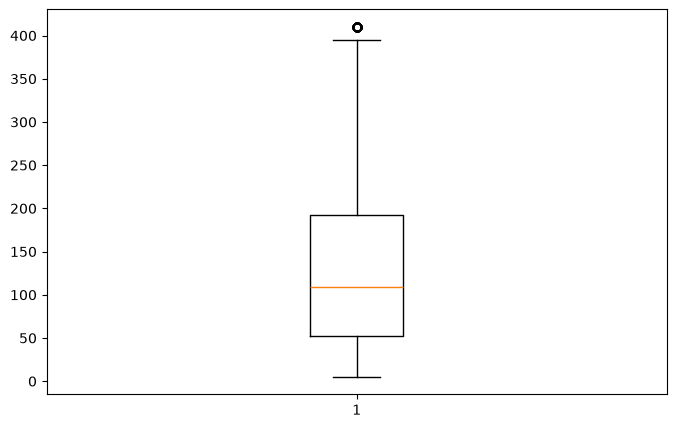

228      410.0
349      410.0
664      410.0
675      410.0
755      410.0
         ...  
19017    410.0
19537    410.0
19558    410.0
19968    410.0
20343    410.0
Name: Total Spent, Length: 99, dtype: float64

In [26]:
OutlierCheck(df['Total Spent'])

In [27]:
df[df['Total Spent'] == 410].head(5) # 410 = 10*41 so it's reasonable number 

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
228,TXN_1860120,CUST_01,Furniture,Item_25_FUR,41.0,10,410.0,Digital Wallet,Online,2022-01-19,True
349,TXN_6651911,CUST_22,Food,Item_25_FOOD,41.0,10,410.0,Digital Wallet,Online,2022-01-28,True
664,TXN_2208547,CUST_05,Beverages,Item_25_BEV,41.0,10,410.0,Credit Card,Online,2022-02-23,True
675,TXN_5150834,CUST_13,Electric household essentials,Item_25_EHE,41.0,10,410.0,Digital Wallet,Online,2022-02-24,True
755,TXN_1657130,CUST_16,Electric household essentials,Item_25_EHE,41.0,10,410.0,Cash,In-store,2022-03-02,True


# Validation Checks 

In [28]:
# Lets select one null row in the original df 👇
original_df = pd.read_csv(file_path)
original_df[(original_df['Price Per Unit'].isnull())].head(1)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [29]:
# lets check using Transaction ID how it is filled in the modified df 👇
# this item is the item in cat_price_group with the same category and price ✅

df[df['Transaction ID'] == 'TXN_7482416']

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7767,TXN_7482416,CUST_09,Patisserie,Item_11_PAT,20.0,10,200.0,Credit Card,Online,2023-11-30,True


## Price Per Unit 200/10 = 20 ✅


In [30]:
# Search in Category_Price_Group (Contains each item with its price)

Cat_Price_Group[(Cat_Price_Group['Category'] == 'Patisserie') & (Cat_Price_Group['Price Per Unit']==20)]

,Category,Price Per Unit,IsPriceUnique,name
185,Patisserie,20.0,1,Item_11_PAT


In [31]:
Missing_summery #✅

,Missing Values,Missing Percentage %
Transaction ID,0,0.0
Customer ID,0,0.0
Category,0,0.0
Item,0,0.0
Price Per Unit,0,0.0
Quantity,0,0.0
Total Spent,0,0.0
Payment Method,0,0.0
Location,0,0.0
Transaction Date,0,0.0


# Importing CSV File 

In [32]:
df.to_csv('Cleaned_Nafazly_Project.csv',index=False)